In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
TF = pd.read_csv('../../Figures/Figures_08022026/Neuropep_TF_corr_hypo_08032026.csv', index_col = 'Unnamed: 0').T
UR = pd.read_csv('../../Figures/Figures_08022026/TF_unregulated_corr_hypo_ncontrols5_08032026.csv', index_col = 'Unnamed: 0').T

In [3]:
TF.shape[0]

31

In [4]:
fin_org = ['mouse' for i in range(TF.shape[0])] + ['vole' for i in range(TF.shape[0])] + ['quail' for i in range(TF.shape[0])] + ['anole' for i in range(TF.shape[0])] + ['xenopus' for i in range(TF.shape[0])] + ['zebrafish' for i in range(TF.shape[0])] + ['mouse' for i in range(UR.shape[0])] + ['vole' for i in range(UR.shape[0])] + ['quail' for i in range(UR.shape[0])] + ['anole' for i in range(UR.shape[0])] + ['xenopus' for i in range(UR.shape[0])] + ['zebrafish' for i in range(UR.shape[0])]
fin_val = list(TF['mm']) + list(TF['mo']) + list(TF['cj']) + list(TF['ac']) + list(TF['xt']) + list(TF['dr']) + list(UR['mm']) + list(UR['mo']) + list(UR['cj']) + list(UR['ac']) + list(UR['xt']) + list(UR['dr'])
fin_genetype = ['TF' for i in range(TF.shape[0] * 6)] + ['Unreg' for i in range(UR.shape[0] * 6)]

In [5]:
len(fin_org),len(fin_val),len(fin_genetype),

(1116, 1116, 1116)

In [6]:
plt_df = pd.DataFrame(data = [fin_org,fin_val,fin_genetype], columns = [i for i in range(len(fin_genetype))], index = ['org','val','genetype']).T

In [7]:
plt_df[plt_df['org'] == 'mouse']

,org,val,genetype
0,mouse,0.405647,TF
1,mouse,0.309298,TF
2,mouse,0.5974,TF
3,mouse,0.424799,TF
4,mouse,0.332997,TF
...,...,...,...
336,mouse,0.444693,Unreg
337,mouse,0.444548,Unreg
338,mouse,0.445311,Unreg
339,mouse,0.445334,Unreg


/scratch/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


(array([ 1.,  3., 16., 36., 23., 21., 17.,  6.,  5.,  2.]),
 array([-0.332933460498355, -0.2527000156799842, -0.17246657086161338,
        -0.09223312604324257, -0.011999681224871772, 0.06823376359349903,
        0.14846720841186983, 0.22870065323024064, 0.30893409804861144,
        0.38916754286698224, 0.4694009876853531], dtype=object),
 <BarContainer object of 10 artists>)

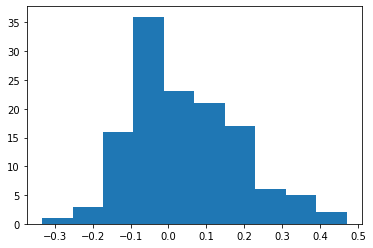

In [8]:
plt.hist(plt_df[plt_df['org'] == 'quail'][plt_df['genetype'] == 'Unreg']['val'], bins = 10)

In [9]:
plt_df['val'] = plt_df['val'].astype(float)

In [17]:
df_p = []
df_org = []
for item in plt_df['org'].unique():
    stat, p = stats.mannwhitneyu(plt_df[(plt_df['org'] == item) & (plt_df['genetype'] == 'TF')]['val'].dropna(), 
                             plt_df[(plt_df['org'] == item) & (plt_df['genetype'] == 'Unreg')]['val'].dropna(), alternative = 'greater')
    df_p.append(p)
    df_org.append(item)

In [18]:
df_stat =pd.DataFrame(data = df_p, columns = [0], index = df_org)

In [19]:
df_stat.to_csv('../../Figures/Figures_08022026/Figure3G_pvals_pearson_ncontrols5_08052026.csv')

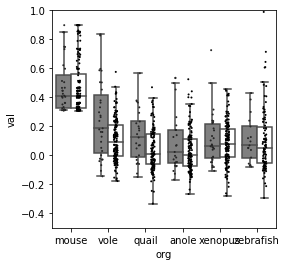

In [34]:
plt.figure(figsize=(4,4))
ax = sns.boxplot(data=plt_df, x='org', y='val', hue='genetype',
                 palette={'TF': 'grey', 'Unreg': 'white'},fliersize = 0)

sns.stripplot(data=plt_df, x='org', y='val', hue='genetype',
              color='black', dodge=True, s = 2)

# Remove the doubled legend from boxplot
ax.legend_.remove()  # then add back manually if needed
plt.ylim(-0.5,1)

plt.savefig('../../Figures/Figures_08022026/Figure3G_unreg_NP_pearson_ncontrol5_08032026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_08022026/Figure3G_unreg_NP_pearson_ncontrol5_08032026.png',dpi =300,bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/Figure3G_unreg_NP_pearson_ncontrol5_08032026.pdf',bbox_inches='tight')